In [1]:
!pip install scikit-learn numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### Bunch Object


```
from scikit-learn.utils import Bunch
```
extend from Dict<br>
Bunch['key'] = Bunch.key = (data, target, taget_names, feture_names, DESCR, filename)



```
Bunch.data: ndarray(150,4) = feature matrix, #150 datas for 4 feature
Bunch.target: ndarray(150,) = tag, 0/1/2
Bunch.target_names: ndarray(3, ) = ['setosa', 'versicolor', 'virginica']
Bunch.feature_names: list[str] = [4 feature_names]
Bunch.DESCR: str = dataset Describtion
Bunch.filename: str = local path of .csv

```

<br>
**note** :ValueError: Found input variables with inconsistent numbers of samples: [120, 150]
sol: stratify = y_temp not y

```
X_train, X_val, y_train, y_val  = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
```


### standarizatoin training data
fit trainsform traini data only<br>
to avoid the largest varience and gradient exploding

$ argmax_{\theta} log( p(X|\theta)) $
<br>
- L1 Lasso(laplace)
$ -\sum \frac{|\theta_i|}{b} $
- L2 Ridge(Gaussian)
$ -\sum \frac{\theta_i^2}{2 \sigma ^2} $
<br>
in sklearn **$ c = 2 \sigma ^2 $**




In [7]:
# load , split data and standardrization
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X, y = load_iris(return_X_y=True)
df = pd.DataFrame(X)

df.info()
df.describe()


# temp(0.8, train:0.6+val:0.2) test(0.2)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val  = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

z = StandardScaler()
X_train = z.fit_transform(X_train)
X_val, X_test = z.transform(X_val), z.transform(X_test)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


### Logistic Regression


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  accuracy_score

acc_result = {}

model = LogisticRegression(C=1,max_iter=500)
model.fit(X_train, y_train)
LR_train_accuracy = accuracy_score(y_train, model.predict(X_train))
LR_val_accuracy = accuracy_score(y_val, model.predict(X_val))

acc_result['Logistic Regression'] = {
    'train_accuracy': LR_train_accuracy, 
    'validation_accuracy': LR_val_accuracy,
}



### SVM

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='rbf', C=1)
model.fit(X_train,y_train)
SVM_train_accuracy = accuracy_score(y_train, model.predict(X_train))
SVM_val_accuracy = accuracy_score(y_val, model.predict(X_val))

acc_result['SVM'] ={
    'train_accuracy':SVM_train_accuracy,
    'validation_accuracy': SVM_val_accuracy,
}


<Axes: >

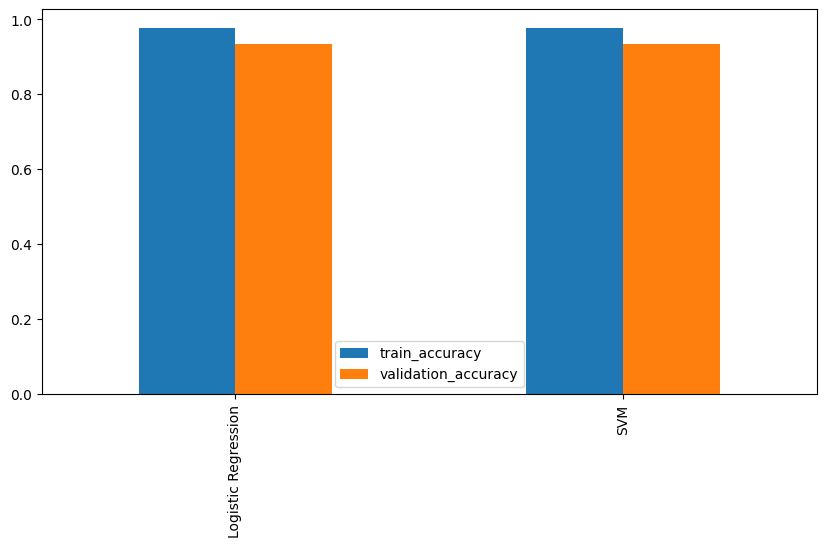

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
df_res = pd.DataFrame(acc_result).T
df_res.plot(kind='bar',figsize=(10,5))

### overfitting practice(SVM)

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

for c in [0.01, 0.1, 1, 10]:
    model = SVC(kernel='rbf',C=c).fit(X_train, y_train)
    print(f"c = {c}")
    print(f"SVM \n {classification_report(y_val, model.predict(X_val))}")

c = 0.01
SVM 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.78      0.70      0.74        10
           2       0.73      0.80      0.76        10

    accuracy                           0.83        30
   macro avg       0.84      0.83      0.83        30
weighted avg       0.84      0.83      0.83        30

c = 0.1
SVM 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.80      0.80      0.80        10
           2       0.80      0.80      0.80        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30

c = 1
SVM 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90 

### confusion matrix(SVM)
2\*2(TP,FP,TN,FN,) <br>
-> 3*3
- 對角線：TP
- row中非對角線:FN
- column中非對角線:FP
- otherwise: TN

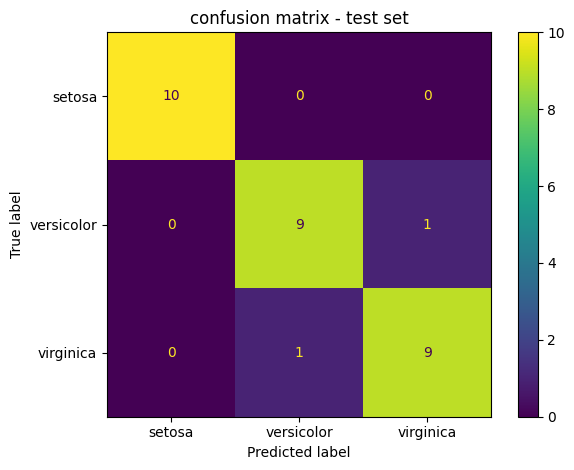

In [25]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay

iris = load_iris()
iris_tar = iris.target_names

model = SVC(kernel='rbf', C=1).fit(X_train, y_train)
test_pred_y = model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, test_pred_y,display_labels=iris_tar)
plt.title('confusion matrix - test set')
plt.tight_layout()
plt.show()